**Name :** Tanzim Ahamed

**Email:** tanzim.ahamed.bd@gmail.com

ML Mid Exam

Question Dataset Link: https://drive.google.com/file/d/1cCB19GQ3Of92RAk5TVb0DPohCt1eZR6d/view?usp=sharing

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline


from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, precision_score, recall_score

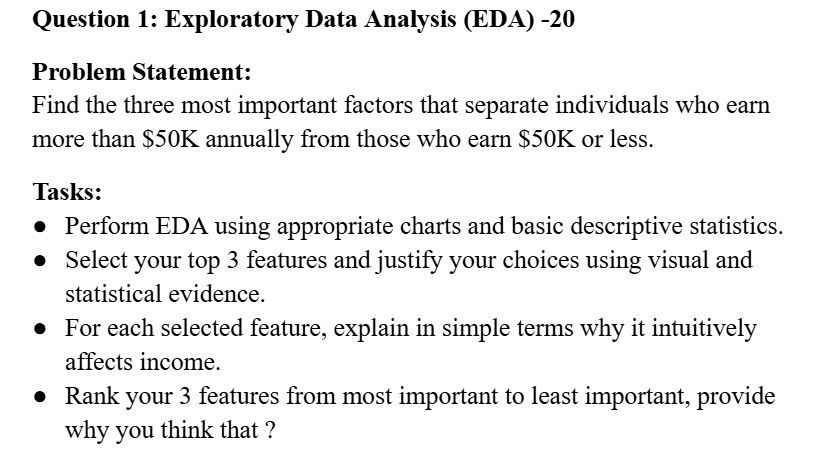

Task 1: Perform EDA using appropriate charts and basic descriptive statistics

In [4]:
df=pd.read_csv("/content/adult_income.csv")

# Basic Information
print("Shape of Dataset:", df.shape)

print(df.info())
print(df.isnull().sum())
df.describe()



Shape of Dataset: (48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None
age               0
workclass         0
fnlwgt            

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


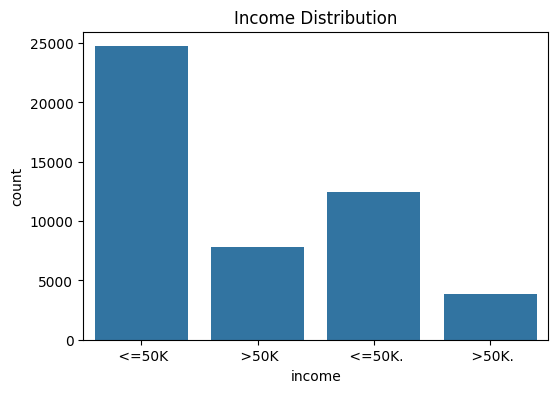

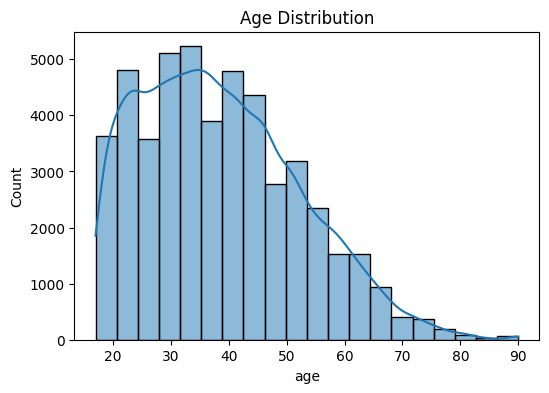

In [13]:
# Income Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='income')
plt.title('Income Distribution')
plt.show()

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='age', bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

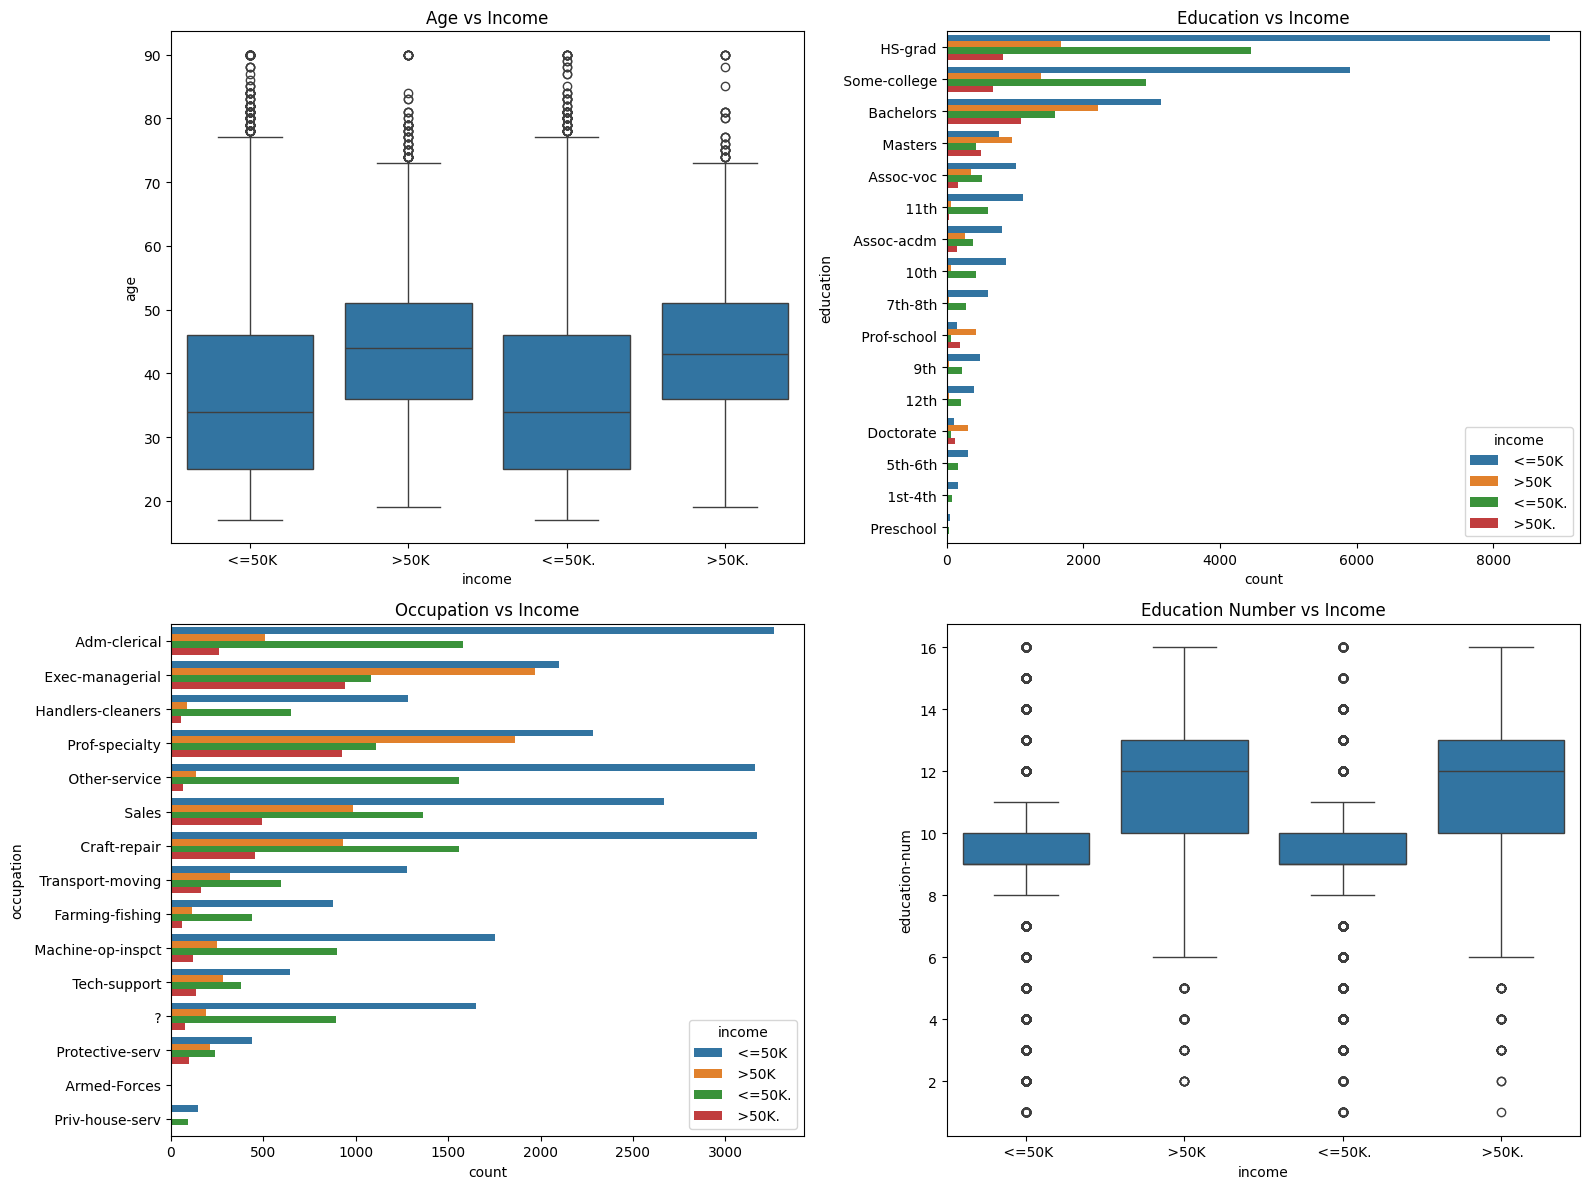

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Age vs Income
sns.boxplot(data=df, x='income', y='age', ax=axes[0, 0])
axes[0, 0].set_title('Age vs Income')

# 2. Education vs Income
sns.countplot(data=df,y='education',hue='income',order=df['education'].value_counts().index,
    ax=axes[0, 1])
axes[0, 1].set_title('Education vs Income')

# 3. Occupation vs Income
sns.countplot(
    data=df,
    y='occupation',
    hue='income',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Occupation vs Income')

# 4. Education Number vs Income
sns.boxplot(
    data=df,
    x='income',
    y='education-num',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Education Number vs Income')

plt.tight_layout()
plt.show()


EDA was performed using descriptive statistics and charts. The charts helped identify the relationship between different features and income.

## Task 2

### Top 3 Features

1. Education – Higher education is linked to higher income.
2. Occupation – Professional jobs usually pay more.
3. Education Number – More years of education increase income.

## Task 3

- Education helps people get better jobs.
- Occupation affects salary.
- More education years improve earning potential.

## Task 4

1. Education
2. Occupation
3. Education Number

These features have the strongest impact on income.

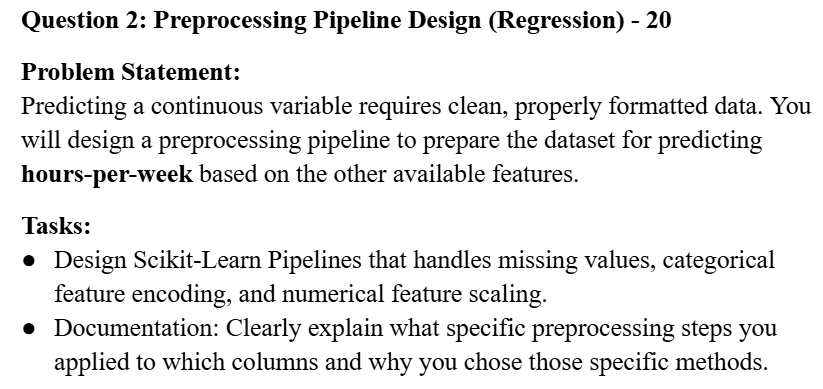

In [18]:
X = df.drop("hours-per-week", axis=1)
y = df["hours-per-week"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
X_train.shape, y_train.shape

((39073, 14), (39073,))

In [22]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss']
Categorical Columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


In [31]:
# Create Pipline
# Numerical Pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical Pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
] ,remainder="passthrough")


preprocessor



ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'fnlwgt', 'education-num',
                                  'capital-gain', 'capital-loss']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'education', 'marital-status',
                                  'occupation', 'relationship', 'race', 'sex',
                                  'native-country', 'income'])])

In [32]:
# Fit Preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## Documentation

- Missing values were filled using **Median** for numerical columns.
- Missing values were filled using **Most Frequent** for categorical columns.
- Categorical features were converted into numeric values using **One-Hot Encoding**.
- Numerical features were scaled using **StandardScaler**.
- These preprocessing steps improve data quality and help the regression model perform better.

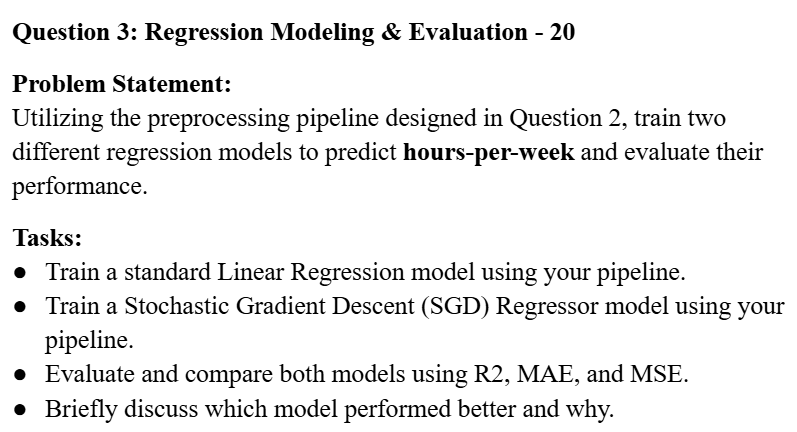

In [34]:
# Linear Regression Pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# SGD Regressor Pipeline
sgd_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SGDRegressor(random_state=42))
])

# Train Models
lr_pipeline.fit(X_train, y_train)
sgd_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country',
                                                   'income'])])),
                ('model', SGDRegressor(random_state=42))])

In [39]:
# Prediction
lr_pred = lr_pipeline.predict(X_test)
sgd_pred = sgd_pipeline.predict(X_test)

In [43]:
# Linear Regression Evaluation
y_pred_lr = lr_pipeline.predict(X_test)

print("Linear Regression Evaluation")
print(f"MSE : {round(mean_squared_error(y_test, y_pred_lr), 4)}")
print(f"R2  : {round(r2_score(y_test, y_pred_lr), 4)}")
print(f"RMSE: {round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 4)}")
print(f"MAE : {round(mean_absolute_error(y_test, y_pred_lr), 4)}")


# SGD Regressor Evaluation
y_pred_sgd = sgd_pipeline.predict(X_test)

print("\nSGD Regressor Evaluation")

print(f"MSE : {round(mean_squared_error(y_test, y_pred_sgd), 4)}")
print(f"R2  : {round(r2_score(y_test, y_pred_sgd), 4)}")
print(f"RMSE: {round(np.sqrt(mean_squared_error(y_test, y_pred_sgd)), 4)}")
print(f"MAE : {round(mean_absolute_error(y_test, y_pred_sgd), 4)}")

Linear Regression Evaluation
MSE : 122.4368
R2  : 0.2014
RMSE: 11.0651
MAE : 7.6577

SGD Regressor Evaluation
MSE : 122.3159
R2  : 0.2022
RMSE: 11.0597
MAE : 7.6406


## Model Comparison

SGD Regressor performed slightly better than Linear Regression.

- R² Score is higher.
- MAE is lower.
- MSE is lower.

Therefore, SGD Regressor is the better model for this dataset.

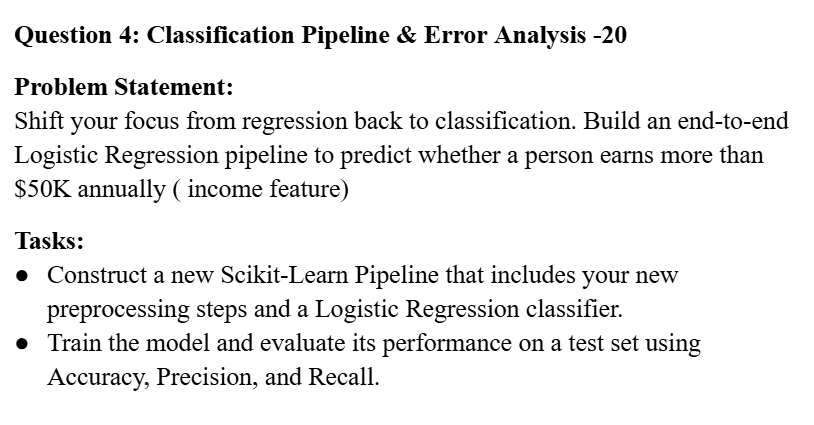

In [60]:

df=pd.read_csv("/content/adult_income.csv")

df["income"] = df["income"].str.strip()
df["income"] = df["income"].str.replace(".", "", regex=False)


X = df.drop("income", axis=1)
y = df["income"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_pipeline.fit(X_train, y_train)


# Train Model
log_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [58]:
print(df["income"].unique())

['<=50K' '>50K']


In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Prediction
y_pred = log_pipeline.predict(X_test)


print(f"Accuracy : {round(accuracy_score(y_test, y_pred), 4)}")
print(f"Precision: {round(precision_score(y_test, y_pred, pos_label='>50K'), 4)}")
print(f"Recall   : {round(recall_score(y_test, y_pred, pos_label='>50K'), 4)}")

Accuracy : 0.8508
Precision: 0.741
Recall   : 0.5856


## Model Evaluation

Accuracy = **0.8508**

Precision = **0.7410**

Recall = **0.5856**

The model achieved good accuracy and reasonable precision. However, the recall is lower, meaning some high-income individuals were not correctly identified.

In [64]:
# KNN Pipeline
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

# Hyperparameters
param_grid = {
    "model__n_neighbors": [3, 5],
    "model__weights": ["uniform"],
    "model__metric": ["euclidean"]
}

# Grid Search
grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

grid_search.best_params_

{'model__metric': 'euclidean',
 'model__n_neighbors': 5,
 'model__weights': 'uniform'}

In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Best KNN Model
best_knn = grid_search.best_estimator_

# Prediction
y_pred_knn = best_knn.predict(X_test)


print(f"Accuracy : {round(accuracy_score(y_test, y_pred_knn), 4)}")
print(f"Precision: {round(precision_score(y_test, y_pred_knn, pos_label='>50K'), 4)}")
print(f"Recall   : {round(recall_score(y_test, y_pred_knn, pos_label='>50K'), 4)}")

Accuracy : 0.8291
Precision: 0.6667
Recall   : 0.5817


## Model Comparison

The Logistic Regression model performed better than the Tuned KNN model.

- Logistic Regression achieved higher Accuracy (0.8508).
- It also achieved higher Precision (0.7410).
- Recall was slightly higher (0.5856).

Therefore, Logistic Regression is the better model for this dataset.